# **Spotify Music Genre Classification Using Machine Learning**


---


## 1. Introduction

Music streaming platforms contain large collections of songs belonging to different music genres. Automatically classifying songs into their respective genres can help organize music libraries, improve music discovery, and support recommendation systems.

This case study uses supervised machine learning algorithms to predict the genre of a Spotify track based on its musical characteristics and audio features.

## 2. Problem Statement

The objective is to develop a multiclass classification model that predicts the music genre (`track_genre`) of a Spotify track using the available features in the dataset.

## 3. Objectives

- Load and explore the Spotify tracks dataset.
- Perform data cleaning and preprocessing.
- Train five machine learning classification algorithms.
- Evaluate the models using accuracy, precision, recall, and F1-score.
- Visualize and compare model performance using graphs and confusion matrices.
- Identify the best-performing model among the five tested algorithms.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


## 4. Dataset Description

The Spotify tracks dataset contains information about songs and their musical characteristics.

The target variable is `track_genre`, which represents the music genre to be predicted. The input features include popularity, duration, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, and other available attributes.

Since the target variable contains multiple music genres, this task is treated as a **multiclass supervised classification problem**.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving spotify-tracks.csv to spotify-tracks (1).csv


In [ ]:
import io

file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Number of rows: 114000
Number of columns: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, quality, and distribution of the Spotify dataset before applying machine learning algorithms.

This section examines the dataset dimensions, column names, data types, missing values, duplicate records, and distribution of music genres. Visualizations are also used to understand selected characteristics of the dataset.

In [ ]:
# Display the dataset dimensions
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types and non-null counts
print("\nDataset information:")
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Check number of unique genres
print("\nNumber of unique genres:", df["track_genre"].nunique())

# Display the first 10 genre counts
print("\nFirst 10 genre counts:")
print(df["track_genre"].value_counts().head(10))

Dataset shape: (114000, 21)

Column names:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy         

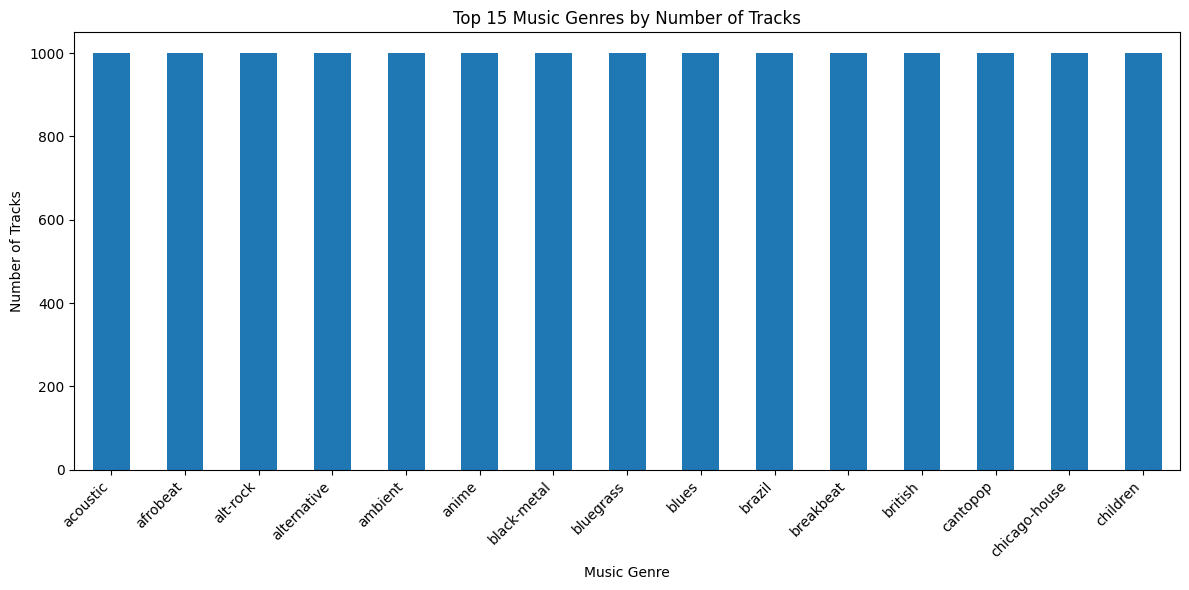

In [ ]:
# Display the 15 most frequent genres
genre_counts = df["track_genre"].value_counts().head(15)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind="bar")

plt.title("Top 15 Music Genres by Number of Tracks")
plt.xlabel("Music Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Analysis of Spotify Audio Features

Spotify audio features describe different characteristics of a track. Danceability indicates how suitable a track is for dancing, energy represents its intensity, valence describes its musical positivity, and tempo indicates its speed in beats per minute.

Examining the distribution of these features helps us understand the data used by the classification algorithms.

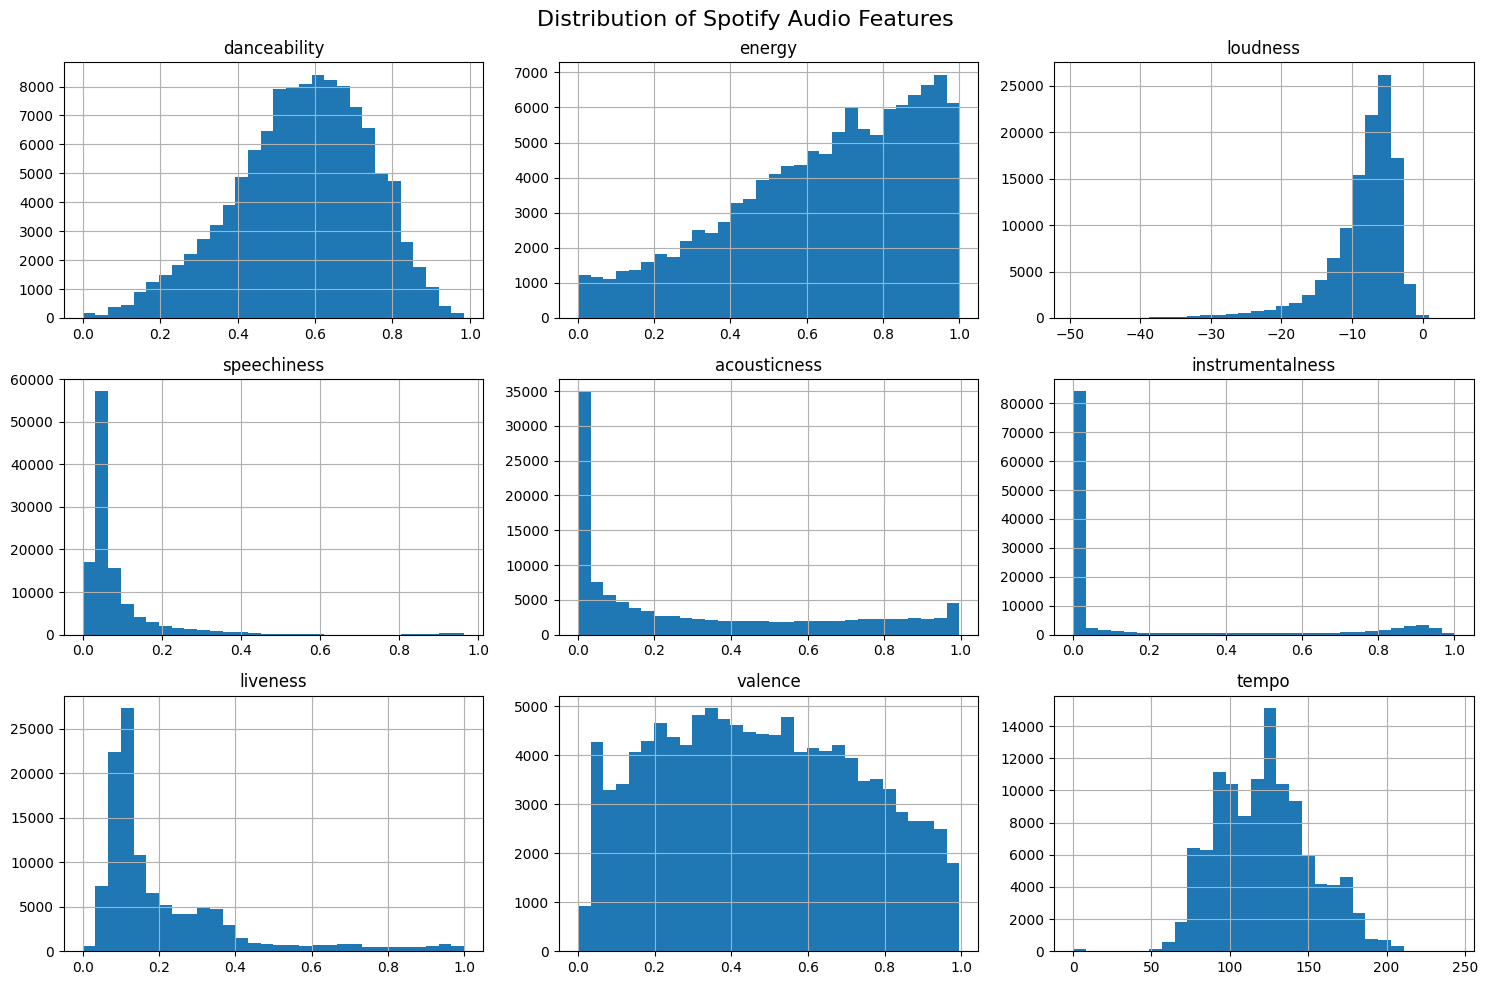

In [ ]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

# Keep only features that exist in the dataset
audio_features = [col for col in audio_features if col in df.columns]

df[audio_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Spotify Audio Features", fontsize=16)
plt.tight_layout()
plt.show()

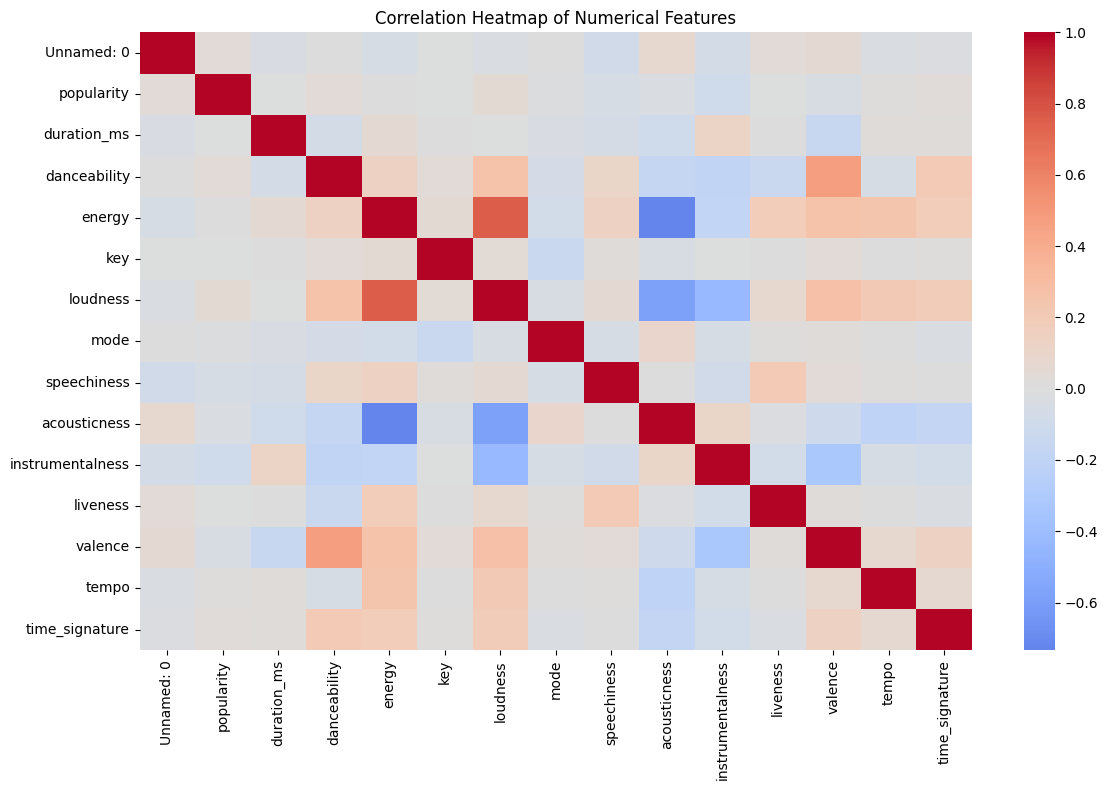

In [ ]:
numeric_features = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_features.corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# 7. Data Preprocessing

Data preprocessing is an essential step in machine learning because raw data may contain missing values, irrelevant columns, and categorical variables that cannot be directly used by many algorithms.

In this case study, preprocessing involves removing unnecessary identifiers and text columns, handling missing values, encoding categorical features, separating the input features from the target variable, splitting the dataset into training and testing sets, and scaling numerical features where required.

The dataset is divided into 80% training data and 20% testing data. Stratified splitting is used to preserve the genre proportions in both sets.

In [ ]:
# Create a copy to preserve the original dataset
data = df.copy()

# Remove unnecessary index and identifier columns if present
columns_to_drop = [
    "Unnamed: 0",
    "track_id",
    "artists",
    "album_name",
    "track_name"
]

data.drop(
    columns=[col for col in columns_to_drop if col in data.columns],
    inplace=True
)

# Remove rows with missing values
data.dropna(inplace=True)

# Remove rows with missing target labels, if any remain
data = data.dropna(subset=["track_genre"])

print("Data cleaning completed.")
print("Shape after cleaning:", data.shape)
print("Remaining missing values:", data.isnull().sum().sum())

Data cleaning completed.
Shape after cleaning: (114000, 16)
Remaining missing values: 0


In [ ]:
# Input features
X = data.drop(columns=["track_genre"]).copy()

# Target variable
y = data["track_genre"].copy()

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)
print("Number of genres:", y.nunique())

print("\nTarget genre examples:")
print(y.head())

Input feature shape: (114000, 15)
Target shape: (114000,)
Number of genres: 114

Target genre examples:
0    acoustic
1    acoustic
2    acoustic
3    acoustic
4    acoustic
Name: track_genre, dtype: object


In [ ]:
# Identify categorical columns
categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical columns:", categorical_columns)

# One-hot encode categorical input features
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

# Ensure all feature columns are numeric
X = X.apply(pd.to_numeric, errors="raise")

print("\nEncoding completed.")
print("Number of encoded features:", X.shape[1])
print("All features numeric:", all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in X.dtypes
))

Categorical columns: ['explicit']

Encoding completed.
Number of encoded features: 16
All features numeric: True


In [ ]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Target encoding completed.")
print("Number of classes:", len(label_encoder.classes_))
print("Example genre labels:", label_encoder.classes_[:10])

Target encoding completed.
Number of classes: 114
Example genre labels: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of input features:", X_train.shape[1])

Training samples: 91200
Testing samples: 22800
Number of input features: 16


In [ ]:
scaler = StandardScaler()

# Fit the scaler only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training shape: (91200, 16)
Scaled testing shape: (22800, 16)


## 8. Preprocessing Summary

The dataset has been cleaned by removing unnecessary columns and rows with missing values. Categorical input features have been converted into numerical representations, and the target variable has been label-encoded.

The data has been divided into training and testing sets using an 80:20 ratio. Standardization has been applied to the features for algorithms that benefit from scaling.

The prepared datasets are now ready for training and evaluating the five classification algorithms.

# 9. Model Building

In this section, five supervised machine learning classification algorithms are trained to predict the music genre of Spotify tracks.

The algorithms selected are:

1. **Logistic Regression:** A classification algorithm that estimates the probability of a class.
2. **K-Nearest Neighbors (KNN):** Predicts the class based on the nearest training samples.
3. **Decision Tree:** Classifies data using a sequence of feature-based decision rules.
4. **Random Forest:** Combines multiple decision trees to produce a classification prediction.
5. **Linear Support Vector Machine (SVM):** Finds decision boundaries that separate classes in the feature space.

All models are trained using the same training dataset and evaluated on the same test dataset for a fair comparison.

In [ ]:
# Dictionary to store trained models and predictions
models = {}
predictions = {}
results = []

# 1. Logistic Regression
print("Training Logistic Regression...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
predictions["Logistic Regression"] = lr.predict(X_test_scaled)
models["Logistic Regression"] = lr


# 2. K-Nearest Neighbors
print("Training K-Nearest Neighbors...")

knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)
predictions["KNN"] = knn.predict(X_test_scaled)
models["KNN"] = knn


# 3. Decision Tree
print("Training Decision Tree...")

dt = DecisionTreeClassifier(
    max_depth=25,
    random_state=42
)

dt.fit(X_train, y_train)
predictions["Decision Tree"] = dt.predict(X_test)
models["Decision Tree"] = dt


# 4. Random Forest
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
predictions["Random Forest"] = rf.predict(X_test)
models["Random Forest"] = rf


# 5. Linear Support Vector Machine
print("Training Linear SVM...")

svm = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=42
)

svm.fit(X_train_scaled, y_train)
predictions["Linear SVM"] = svm.predict(X_test_scaled)
models["Linear SVM"] = svm

print("\nAll five models have been trained successfully!")

Training Logistic Regression...
Training K-Nearest Neighbors...
Training Decision Tree...
Training Random Forest...
Training Linear SVM...

All five models have been trained successfully!


# 10. Model Evaluation

The trained models are evaluated using the test dataset, which was not used during training.

The following metrics are calculated:

- **Accuracy:** Proportion of test samples classified correctly.
- **Weighted Precision:** Measures the correctness of positive class predictions, accounting for the number of samples in each class.
- **Weighted Recall:** Measures how many actual samples are correctly identified, accounting for class support.
- **Weighted F1-Score:** The weighted harmonic mean of precision and recall.

Weighted averages are used to summarize performance across the 114 music genres while accounting for differences in class support.

In [ ]:
# Clear previous results to avoid duplicates
results = []

# Calculate metrics for each model
for name, y_pred in predictions.items():
    results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        )
    })

# Create a fresh results table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.3249,0.3180,0.3249,0.3181
1,Decision Tree,0.2179,0.2241,0.2179,0.2194
2,Logistic Regression,0.2027,0.1722,0.2027,0.1736
3,KNN,0.2019,0.2191,0.2019,0.2002
4,Linear SVM,0.1739,0.1160,0.1739,0.1113


In [ ]:
best_model_name = results_df.iloc[0]["Algorithm"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print("Best-performing model:", best_model_name)
print(f"Test accuracy: {best_accuracy:.2%}")

Best-performing model: Random Forest
Test accuracy: 32.49%


# 11. Model Performance Visualization

Visualizations provide a clear comparison of the performance of the five classification algorithms. In this section, the models are compared using accuracy, precision, recall, and F1-score.

These visualizations help identify differences in predictive performance and determine which algorithm performs best on the test dataset.

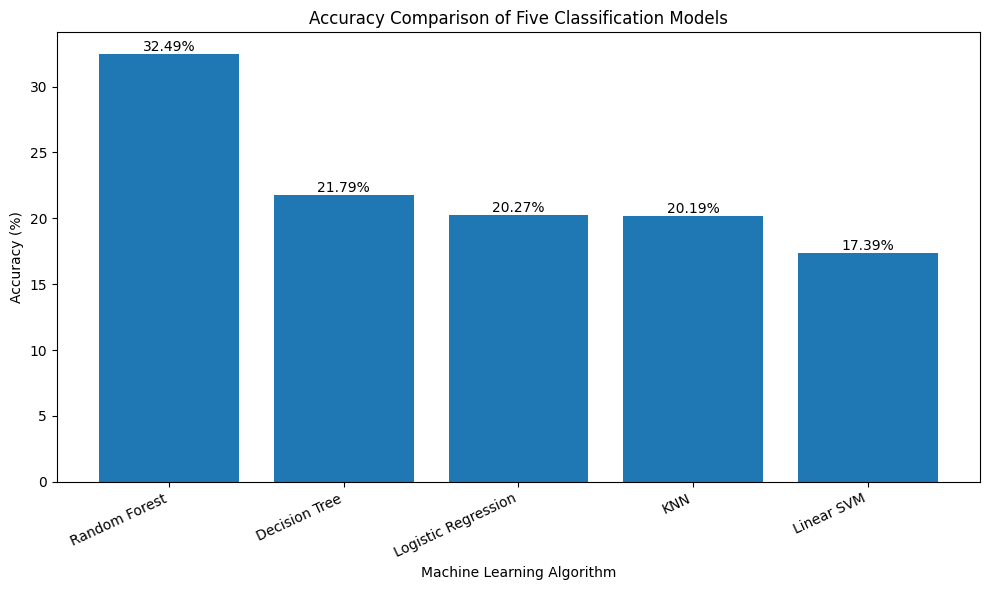

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    results_df["Algorithm"],
    results_df["Accuracy"] * 100
)

plt.title("Accuracy Comparison of Five Classification Models")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

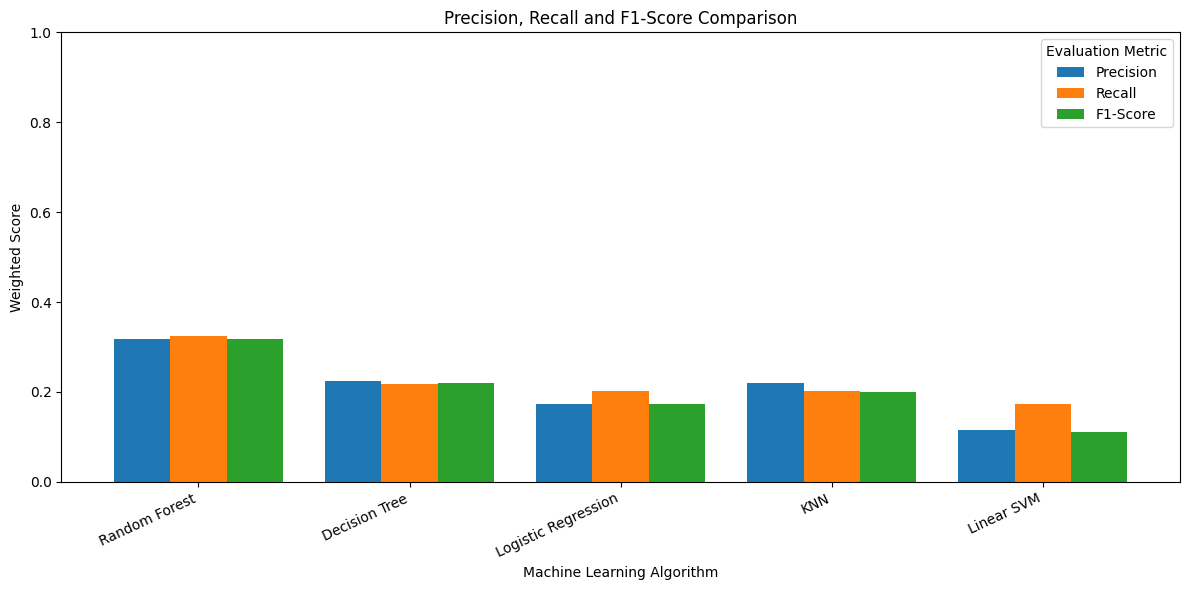

In [ ]:
metrics = ["Precision", "Recall", "F1-Score"]

plot_data = results_df.set_index("Algorithm")[metrics]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_title("Precision, Recall and F1-Score Comparison")
ax.set_xlabel("Machine Learning Algorithm")
ax.set_ylabel("Weighted Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Evaluation Metric")
plt.tight_layout()
plt.show()

## 12. Classification Reports

A classification report provides precision, recall, F1-score, and support for each music genre. These metrics help evaluate how well a model identifies individual genres rather than relying only on overall accuracy.

The weighted averages summarize the performance across all genres while accounting for the number of test samples belonging to each class.

In [ ]:
for name, y_pred in predictions.items():
    print("=" * 75)
    print(f"CLASSIFICATION REPORT: {name}")
    print("=" * 75)

    print(
        classification_report(
            y_test,
            y_pred,
            labels=np.arange(len(label_encoder.classes_)),
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

CLASSIFICATION REPORT: Logistic Regression
                   precision    recall  f1-score   support

         acoustic       0.13      0.12      0.13       200
         afrobeat       0.23      0.14      0.17       200
         alt-rock       0.02      0.01      0.01       200
      alternative       0.06      0.03      0.03       200
          ambient       0.28      0.36      0.31       200
            anime       0.08      0.04      0.05       200
      black-metal       0.45      0.51      0.48       200
        bluegrass       0.26      0.20      0.23       200
            blues       0.00      0.00      0.00       200
           brazil       0.02      0.01      0.01       200
        breakbeat       0.22      0.18      0.20       200
          british       0.00      0.00      0.00       200
         cantopop       0.16      0.18      0.17       200
    chicago-house       0.24      0.37      0.29       200
         children       0.22      0.35      0.27       200
            

## 13. Confusion Matrix Analysis

A confusion matrix compares the actual music genres with the genres predicted by a classification model. Correct predictions appear along the main diagonal, while incorrect predictions appear outside the diagonal.

Since this dataset contains many music genres, each confusion matrix is large. To improve readability, the following visualizations display the overall confusion matrices without printing every genre name on the axes.

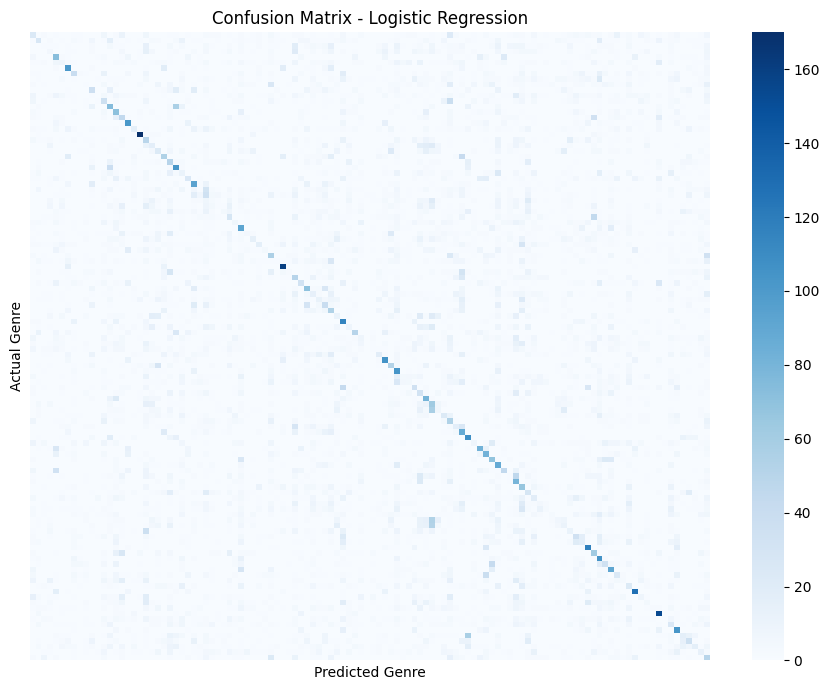

Logistic Regression: confusion matrix shape = (114, 114)


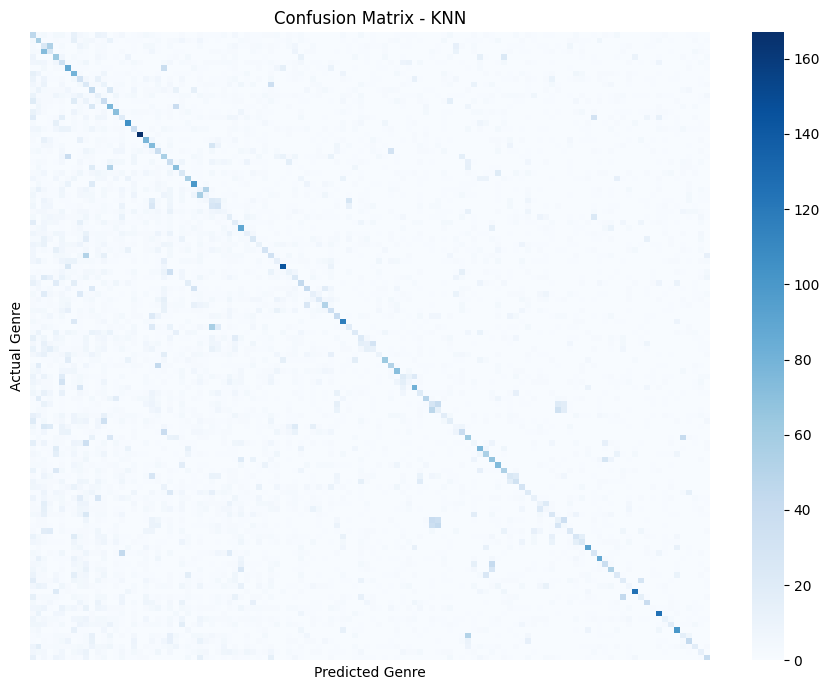

KNN: confusion matrix shape = (114, 114)


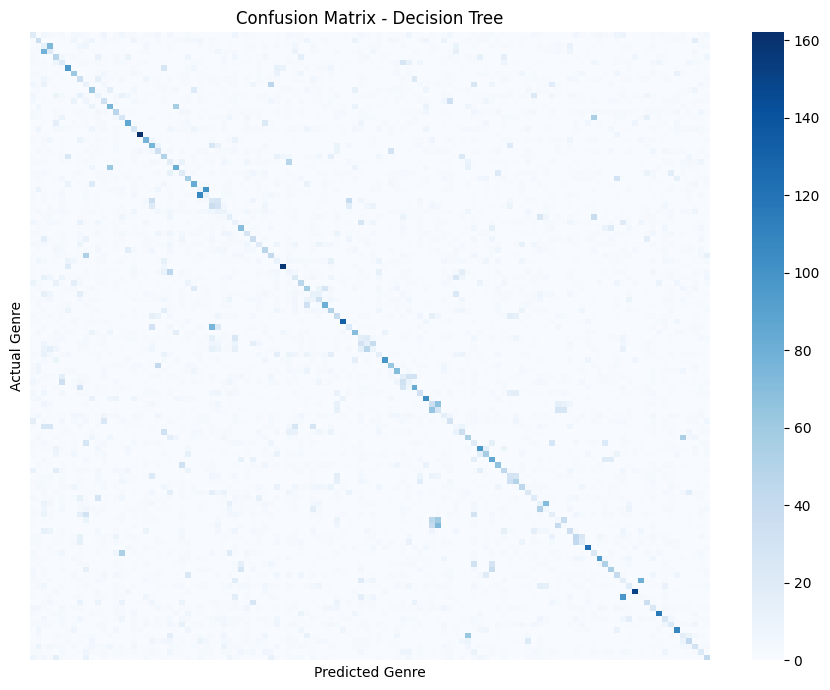

Decision Tree: confusion matrix shape = (114, 114)


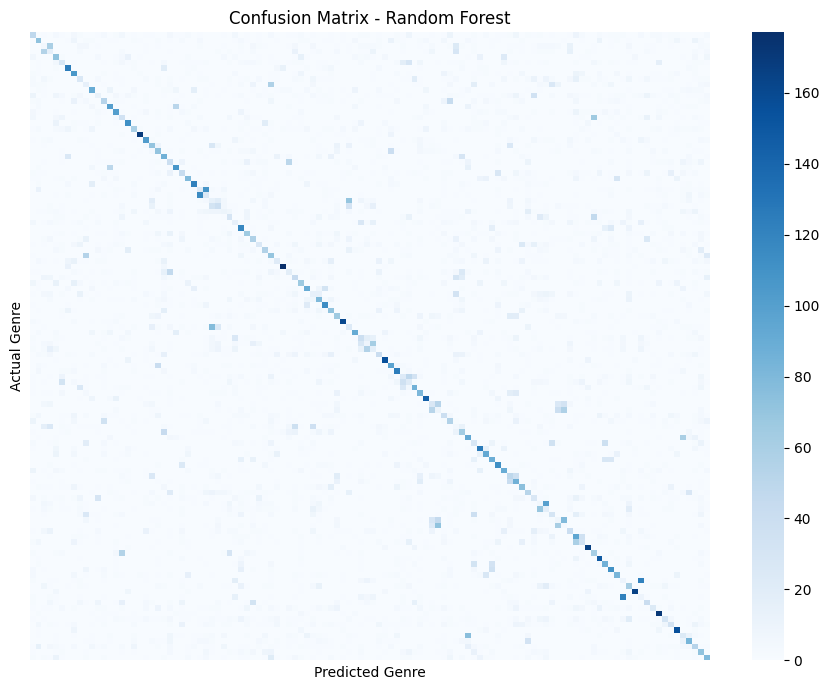

Random Forest: confusion matrix shape = (114, 114)


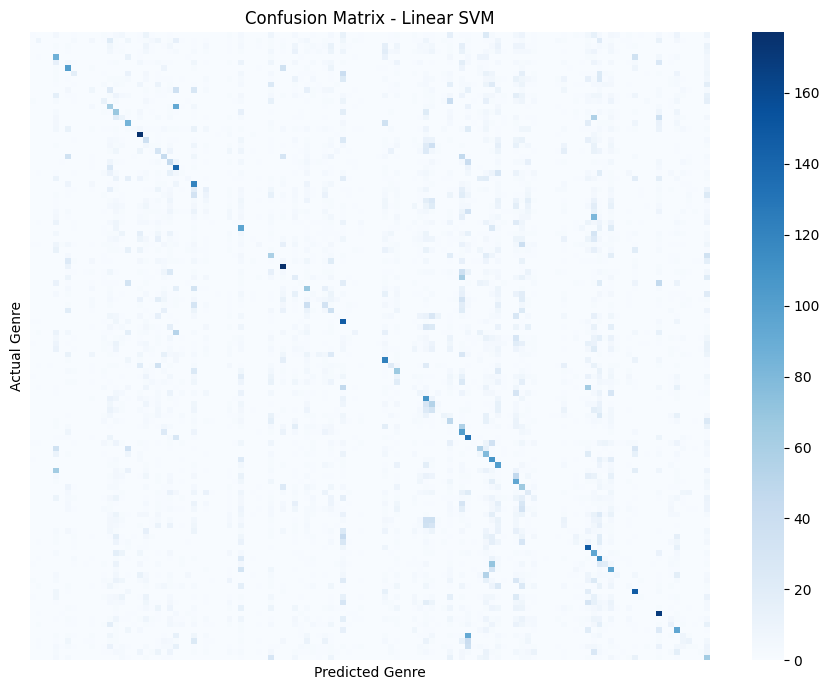

Linear SVM: confusion matrix shape = (114, 114)


In [ ]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=np.arange(len(label_encoder.classes_))
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=False,
        yticklabels=False,
        cbar=True
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Genre")
    plt.ylabel("Actual Genre")
    plt.tight_layout()
    plt.show()

    print(f"{name}: confusion matrix shape = {cm.shape}")

# 14. Results and Discussion

The five supervised machine learning algorithms were evaluated using the same test dataset. Their performance was compared using accuracy, weighted precision, weighted recall, and weighted F1-score.

The accuracy comparison identifies the model that correctly classifies the largest proportion of test samples. The additional evaluation metrics provide further insight into the models' performance across different music genres.

The confusion matrices illustrate the distribution of correct and incorrect predictions for each algorithm. Since the dataset contains multiple music genres, classification performance may vary across individual classes.

The best-performing model is selected based on the highest test accuracy obtained in this experiment.

In [ ]:
# Display the final model comparison table
final_results = results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    final_results[col] = (
        final_results[col] * 100
    ).round(2)

print("FINAL MODEL PERFORMANCE COMPARISON")
display(final_results)

print("\nBest-performing model:", results_df.iloc[0]["Algorithm"])
print(f"Best test accuracy: {results_df.iloc[0]['Accuracy']:.2%}")

FINAL MODEL PERFORMANCE COMPARISON


,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Random Forest,32.49,31.80,32.49,31.81
1,Decision Tree,21.79,22.41,21.79,21.94
2,Logistic Regression,20.27,17.22,20.27,17.36
3,KNN,20.19,21.91,20.19,20.02
4,Linear SVM,17.39,11.60,17.39,11.13



Best-performing model: Random Forest
Best test accuracy: 32.49%


## 15. Best-Performing Model

The model with the highest test accuracy is identified as the best-performing algorithm among the five models evaluated in this case study.

The selection is based on the results obtained from the test dataset. Precision, recall, F1-score, and confusion matrices are also considered to provide a broader understanding of model performance.

In [ ]:
best_row = results_df.iloc[0]

print("=" * 60)
print("BEST-PERFORMING MODEL")
print("=" * 60)
print("Algorithm:", best_row["Algorithm"])
print(f"Accuracy:  {best_row['Accuracy']:.2%}")
print(f"Precision: {best_row['Precision']:.2%}")
print(f"Recall:    {best_row['Recall']:.2%}")
print(f"F1-Score:  {best_row['F1-Score']:.2%}")

BEST-PERFORMING MODEL
Algorithm: Random Forest
Accuracy:  32.49%
Precision: 31.80%
Recall:    32.49%
F1-Score:  31.81%


## 16. Limitations

- The dataset contains many music genres, making the classification task challenging.
- Different genres may share similar audio characteristics.
- The performance of the models depends on the selected features and hyperparameters.
- Some genres may be harder to distinguish than others.
- Further feature engineering, hyperparameter tuning, and alternative classification approaches may improve performance.

The results represent the performance of the selected algorithms under the experimental settings used in this case study.

# 17. Conclusion

This case study implemented five supervised machine learning algorithms to classify Spotify tracks into their respective music genres.

The dataset was explored and preprocessed before training Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, and Linear Support Vector Machine models.

The models were evaluated using accuracy, weighted precision, weighted recall, weighted F1-score, and confusion matrices. Their performance was compared to identify the best-performing algorithm.

The model with the highest test accuracy was selected as the best-performing model among the five algorithms tested. This experiment demonstrates the application of machine learning to multiclass music genre classification and highlights the importance of data preprocessing, model evaluation, and performance comparison.